In [ ]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
import numpy as np
import pandas as pd
pd.options.display.float_format = '{:.2f}'.format

In [ ]:
#Data exploration - load and examine the dataset
qSales = pd.read_csv('qSales_2024.csv')
display(qSales)

,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat
0,1690,2001-03-31,2001,2,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q1,2001Q2,1431.00,A
1,1690,2001-06-30,2001,3,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q2,2001Q3,1475.00,A
2,1690,2001-09-30,2001,4,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q3,2001Q4,1450.00,A
3,1690,2001-12-31,2002,1,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q4,2002Q1,1375.00,A
4,1690,2002-03-31,2002,2,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2002Q1,2002Q2,1495.00,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
272,102450,2022-12-31,2022,3,3,INDL,C,D,STD,NTDOY,NINTENDO CO LTD,USD,2022Q4,2022Q3,5280.78,A
273,102450,2023-03-31,2022,4,3,INDL,C,D,STD,NTDOY,NINTENDO CO LTD,USD,2023Q1,2022Q4,2226.88,A
274,102450,2023-06-30,2023,1,3,INDL,C,D,STD,NTDOY,NINTENDO CO LTD,USD,2023Q2,2023Q1,3190.81,A
275,102450,2023-09-30,2023,2,3,INDL,C,D,STD,NTDOY,NINTENDO CO LTD,USD,2023Q3,2023Q2,2140.04,A


In [ ]:
# change date to datetime type
qSales['datadate'] = pd.to_datetime(qSales['datadate'])

In [ ]:
#filter for just Target
target_sales = qSales.loc[qSales['tic']=='TGT']
display(target_sales)

,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat
92,3813,2001-01-31,2000,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2000Q4,2000Q4,12324.00,A
93,3813,2001-04-30,2001,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q1,2001Q1,8334.00,A
94,3813,2001-07-31,2001,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q2,2001Q2,8941.00,A
95,3813,2001-10-31,2001,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q3,2001Q3,9331.00,A
96,3813,2002-01-31,2001,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q4,2001Q4,13220.00,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180,3813,2023-01-31,2022,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2022Q4,2022Q4,31395.00,A
181,3813,2023-04-30,2023,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q1,2023Q1,25322.00,A
182,3813,2023-07-31,2023,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q2,2023Q2,24773.00,A
183,3813,2023-10-31,2023,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q3,2023Q3,25398.00,A


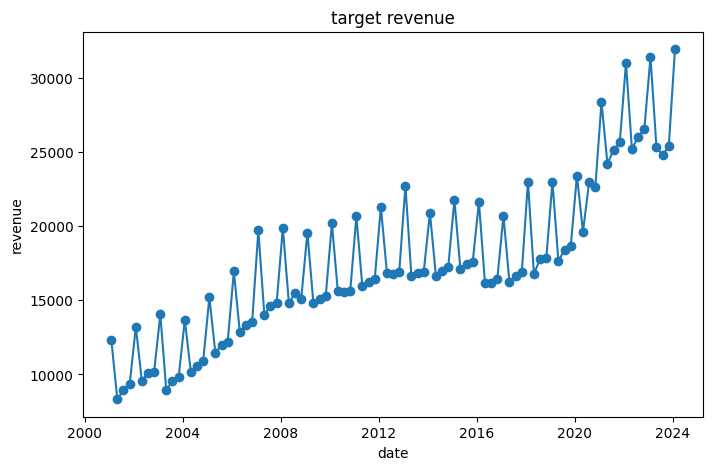

In [ ]:
#Data Exploration: create visualizations to identify underlying patterns
plt.figure(figsize=(8,5))

plt.title('target revenue')
plt.xlabel('date')
plt.ylabel('revenue')

plt.plot(target_sales['datadate'], target_sales['saleq'], marker = 'o')

Patterns visible from visualization: Upward trend over time, consistent sharp peak followed by sharp drop repeating over the period,

In [ ]:
# Add time column
target_sales['time'] = range(1, len(target_sales)+1)

display (target_sales)


/tmp/ipykernel_1736/2023392387.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  target_sales['time'] = range(1, len(target_sales)+1)


,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat,time
92,3813,2001-01-31,2000,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2000Q4,2000Q4,12324.00,A,1
93,3813,2001-04-30,2001,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q1,2001Q1,8334.00,A,2
94,3813,2001-07-31,2001,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q2,2001Q2,8941.00,A,3
95,3813,2001-10-31,2001,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q3,2001Q3,9331.00,A,4
96,3813,2002-01-31,2001,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q4,2001Q4,13220.00,A,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180,3813,2023-01-31,2022,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2022Q4,2022Q4,31395.00,A,89
181,3813,2023-04-30,2023,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q1,2023Q1,25322.00,A,90
182,3813,2023-07-31,2023,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q2,2023Q2,24773.00,A,91
183,3813,2023-10-31,2023,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q3,2023Q3,25398.00,A,92


In [ ]:
# Prep training and testing data
dt4training = target_sales[:int(0.75*len(target_sales))] # takes the first 75% of rows
dt4testing = target_sales[int(0.75*len(target_sales)):] # takes the last 25% of rows

In [ ]:
# Model development

dt4training_copy = dt4training.copy()
#create 2 dummy variables on dt4training_copy
dt4training_copy['dv_q4'] = np.where(dt4training_copy['fqtr'] == 4, 1, 0) #spikes appear to be Q4
dt4training_copy['dv_q1'] = np.where(dt4training_copy['fqtr'] == 1, 1, 0) #dips appear to be Q1

# Build regression model
y = dt4training_copy.loc[:, 'saleq'] # revenue as dependent variable
x = dt4training_copy.loc[:,['time','dv_q4','dv_q1']] # time and 2 dummy variables as independent variables

x = sm.add_constant(x)

model1 = sm.OLS(y,x).fit()

model1.params

,0
const,9399.40
time,139.15
dv_q4,4472.62
dv_q1,-232.80


Interpretation: target revenue = 9399.40 + 139 * time + 4473 * dv_q4 - 233 *dv_q1

In [ ]:
# Analysis output
# visualization showing actual revenue data and models predictions

# Create dummy variables for dt4testing
dt4testing['dv_q4'] = np.where(dt4testing['fqtr'] == 4, 1, 0)
dt4testing['dv_q1'] = np.where(dt4testing['fqtr'] == 1, 1, 0)

x_test = dt4testing.loc[:,['time','dv_q4','dv_q1']]
x_test = sm.add_constant(x_test)

#calculating MAPE score
model1_assessment = dt4testing.copy() # copy it into our new data frame called model1_assessment

model1_assessment['model1_predicted_saleq'] = model1.predict(x_test)

model1_assessment['model1_abs_pct_error'] = abs((model1_assessment['saleq'] - model1_assessment['model1_predicted_saleq']) / model1_assessment['saleq'])

display(model1_assessment)

/tmp/ipykernel_1736/1427604519.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dt4testing['dv_q4'] = np.where(dt4testing['fqtr'] == 4, 1, 0)
/tmp/ipykernel_1736/1427604519.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dt4testing['dv_q1'] = np.where(dt4testing['fqtr'] == 1, 1, 0)


,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,...,curcdq,datacqtr,datafqtr,saleq,costat,time,dv_q4,dv_q1,model1_predicted_saleq,model1_abs_pct_error
161,3813,2018-04-30,2018,1,1,INDL,C,D,STD,TGT,...,USD,2018Q1,2018Q1,16781.00,A,70,0,1,18907.24,0.13
162,3813,2018-07-31,2018,2,1,INDL,C,D,STD,TGT,...,USD,2018Q2,2018Q2,17777.00,A,71,0,0,19279.19,0.08
163,3813,2018-10-31,2018,3,1,INDL,C,D,STD,TGT,...,USD,2018Q3,2018Q3,17821.00,A,72,0,0,19418.34,0.09
164,3813,2019-01-31,2018,4,1,INDL,C,D,STD,TGT,...,USD,2018Q4,2018Q4,22977.00,A,73,1,0,24030.11,0.05
165,3813,2019-04-30,2019,1,1,INDL,C,D,STD,TGT,...,USD,2019Q1,2019Q1,17627.00,A,74,0,1,19463.85,0.10
166,3813,2019-07-31,2019,2,1,INDL,C,D,STD,TGT,...,USD,2019Q2,2019Q2,18422.00,A,75,0,0,19835.80,0.08
167,3813,2019-10-31,2019,3,1,INDL,C,D,STD,TGT,...,USD,2019Q3,2019Q3,18664.00,A,76,0,0,19974.95,0.07
168,3813,2020-01-31,2019,4,1,INDL,C,D,STD,TGT,...,USD,2019Q4,2019Q4,23399.00,A,77,1,0,24586.72,0.05
169,3813,2020-04-30,2020,1,1,INDL,C,D,STD,TGT,...,USD,2020Q1,2020Q1,19615.00,A,78,0,1,20020.46,0.02
170,3813,2020-07-31,2020,2,1,INDL,C,D,STD,TGT,...,USD,2020Q2,2020Q2,22975.00,A,79,0,0,20392.41,0.11


In [ ]:
# MAPE score
model1_assessment['model1_abs_pct_error'].mean()

np.float64(0.11973057147230126)

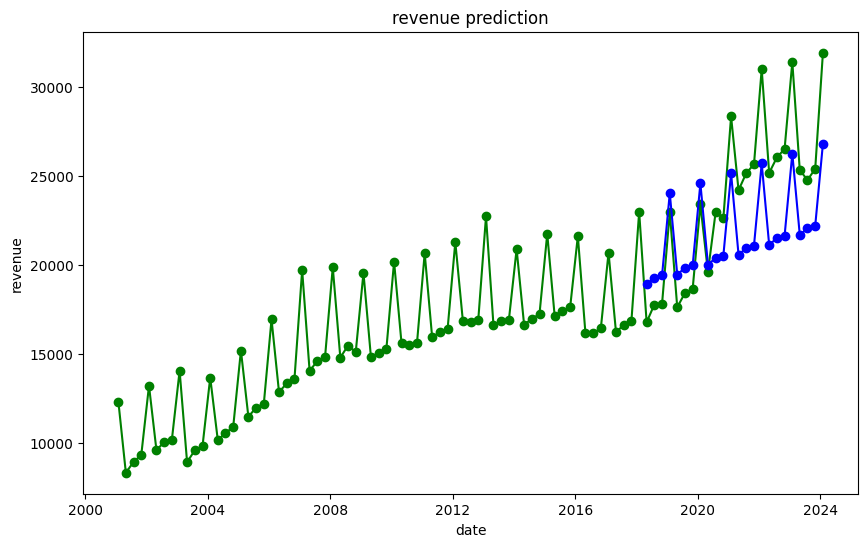

In [ ]:
# make visualization
plt.figure(figsize=(10,6))

plt.title('revenue prediction')
plt.ylabel('revenue')
plt.xlabel('date')

# add the lines
plt.plot(target_sales['datadate'], target_sales['saleq'], marker = 'o', color='green')
plt.plot(model1_assessment['datadate'], model1_assessment['model1_predicted_saleq'], marker = 'o', color='blue')

# To: Chapman Wealth Management
# From: Simran Bal, QuantFolio Solutions
# Date: July 24, 2026
# Re: Target Corporation quarterly revenue analysis

# Bottom line. Target's revenue follows a strong and predictable upward trend with consistent seasonal spikes in Q4 and dips in Q1, which our model captures well.

# Key findings.

# 1. Revenue has grown steadily from 2002 to 2024. The time coefficient of approximately 139 indicates Target adds roughly $139M in revenue per quarter on a trend basis.
# 2. Q4 is Target's strongest quarter. The Q4 dummy adds approximately $4,473M above the trend line, reflecting holiday season demand. This spike is visible and consistent across the entire dataset.
# 3. Q1 is the weakest quarter, coming in approximately $233M below trend, likely reflecting people spending less after the holidays.

# Recommendation: Chapman Wealth Management can reasonably expect continued Q4 outperformance as a recurring feature of Target's business.